In [1]:
import dagshub
dagshub.init(repo_owner="karev23", repo_name="ML-HW-1", mlflow=True)


Accessing as karev23

Initialized MLflow to track repo "karev23/ML-HW-1"

Repository karev23/ML-HW-1 initialized!

shape of train data: (1460, 81)
null values in train data: PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64
target value distribution in train data: Axes(0.125,0.11;0.775x0.77)


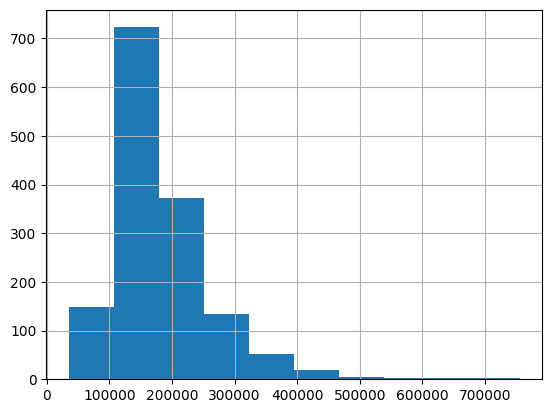

In [2]:
import pandas as pd
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print("shape of train data:", train.shape)
print("null values in train data:", train.isnull().sum().sort_values(ascending=False))
print("target value distribution in train data:", train["SalePrice"].hist())


In [3]:
import numpy as np

# 1. Apply log transformation to target
train["SalePrice"] = np.log1p(train["SalePrice"])


cols_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

# 3. Separate target from features
X = train.drop(columns=["SalePrice"])
y = train["SalePrice"]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## cleaning

In [4]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

LotFrontage     217
MasVnrType      683
MasVnrArea        6
BsmtQual         28
BsmtCond         28
BsmtExposure     28
BsmtFinType1     28
BsmtFinType2     28
Electrical        1
FireplaceQu     547
GarageType       64
GarageYrBlt      64
GarageFinish     64
GarageQual       64
GarageCond       64
dtype: int64


In [5]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
for col in numeric_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_val[col] = X_val[col].fillna(median)

for col in categorical_cols:
    X_train[col] = X_train[col].fillna("None")
    X_val[col] = X_val[col].fillna("None")

## feature engeneering

In [6]:
# which is numeric and which is categorical
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numeric: {numeric_cols} columns")
print(f"Categorical: {categorical_cols} columns")

Numeric: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'] columns
Categorical: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish

## ordinal columns that needs to be turned into numbers 

In [7]:
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0, "NA": 0, "None": 0}
BsmtExposure_map = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "NA": 0, "None": 0}
BsmtFinType_map  = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1,"None":0,  "NA": 0}
GarageFinish_map = {"Fin": 3, "RFn": 2, "Unf": 1, "NA": 0, "None": 0}
Functional_map   = {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0, "NA": 0, "None": 0}
PavedDrive_map   = {"Y": 2, "P": 1, "N": 0, "NA": 0, "None": 0}
LandSlope_map    = {"Gtl": 2, "Mod": 1, "Sev": 0,  "NA": 0, "None": 0}

## columns that has same map (quality map)
ordinal_quality_cols = [
    "ExterQual", "ExterCond",      
    "BsmtQual", "BsmtCond",        
    "HeatingQC",                   
    "KitchenQual",                 
    "GarageQual", "GarageCond",
    "FireplaceQu"   
]

for col in ordinal_quality_cols:
    X_train[col] = X_train[col].map(quality_map)
    X_val[col] = X_val[col].map(quality_map)

##other columns with different maps
X_train["BsmtExposure"] = X_train["BsmtExposure"].map(BsmtExposure_map)
X_val["BsmtExposure"] = X_val["BsmtExposure"].map(BsmtExposure_map)
X_train["BsmtFinType1"] = X_train["BsmtFinType1"].map(BsmtFinType_map)
X_val["BsmtFinType1"] = X_val["BsmtFinType1"].map(BsmtFinType_map)
X_train["BsmtFinType2"] = X_train["BsmtFinType2"].map(BsmtFinType_map)
X_val["BsmtFinType2"] = X_val["BsmtFinType2"].map(BsmtFinType_map)
X_train["GarageFinish"] = X_train["GarageFinish"].map(GarageFinish_map)
X_val["GarageFinish"] = X_val["GarageFinish"].map(GarageFinish_map)
X_train["Functional"] = X_train["Functional"].map(Functional_map)
X_val["Functional"] = X_val["Functional"].map(Functional_map)
X_train["PavedDrive"] = X_train["PavedDrive"].map(PavedDrive_map)
X_val["PavedDrive"] = X_val["PavedDrive"].map(PavedDrive_map)
X_train["LandSlope"] = X_train["LandSlope"].map(LandSlope_map) 
X_val["LandSlope"] = X_val["LandSlope"].map(LandSlope_map)


## nominal columns 

In [8]:
nominal_cols = [
    "MSZoning", "Street", "LotShape", "LandContour",
    "LotConfig", "Neighborhood", "Condition1", "Condition2",
    "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical",
    "GarageType", "SaleType", "SaleCondition", "Utilities"
]
## only has yes or no values, so we can convert it to binary without one-hot encoding
X_train["CentralAir"] = (X_train["CentralAir"] == "Y").astype(int)
X_val["CentralAir"]   = (X_val["CentralAir"] == "Y").astype(int)

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_val   = pd.get_dummies(X_val,   columns=nominal_cols, drop_first=True)
X_train = X_train.astype({col: int for col in X_train.select_dtypes(bool).columns})
X_val   = X_val.astype({col: int for col in X_val.select_dtypes(bool).columns})
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

## new columns for some info that is not good for model

In [9]:
X_train["TotalSF"] = X_train["TotalBsmtSF"] + X_train["1stFlrSF"] + X_train["2ndFlrSF"]
X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
X_train["WasRemodeled"] = (X_train["YearRemodAdd"] != X_train["YearBuilt"]).astype(int)
X_train["TotalBath"] = (X_train["FullBath"] + 0.5 * X_train["HalfBath"] + X_train["BsmtFullBath"] + 0.5 * X_train["BsmtHalfBath"])
X_train["HasGarage"] = (X_train["GarageArea"] > 0).astype(int)
X_train["HasPool"] = (X_train["PoolArea"] > 0).astype(int)
X_train["HasFireplace"] = (X_train["Fireplaces"] > 0).astype(int)
X_train["RemodAge"] = X_train["YrSold"] - X_train["YearRemodAdd"]
X_train["TotalPorch"] = (X_train["OpenPorchSF"] + X_train["EnclosedPorch"] + X_train["3SsnPorch"] + X_train["ScreenPorch"] + X_train["WoodDeckSF"])
X_train["HasBsmt"] = (X_train["TotalBsmtSF"] > 0).astype(int)



X_val["HasBsmt"]   = (X_val["TotalBsmtSF"]   > 0).astype(int)
X_val["TotalPorch"]   = (X_val["OpenPorchSF"]   + X_val["EnclosedPorch"] + X_val["3SsnPorch"]   + X_val["ScreenPorch"]   + X_val["WoodDeckSF"])
X_val["RemodAge"]   = X_val["YrSold"]   - X_val["YearRemodAdd"]
X_val["TotalSF"] = X_val["TotalBsmtSF"] + X_val["1stFlrSF"] + X_val["2ndFlrSF"]
X_val["HouseAge"] = X_val["YrSold"] - X_val["YearBuilt"]
X_val["WasRemodeled"] = (X_val["YearRemodAdd"] != X_val["YearBuilt"]).astype(int)
X_val["TotalBath"] = (X_val["FullBath"] + 0.5 * X_val["HalfBath"] + X_val["BsmtFullBath"] + 0.5 * X_val["BsmtHalfBath"])
X_val["HasGarage"] = (X_val["GarageArea"] > 0).astype(int)
X_val["HasPool"] = (X_val["PoolArea"] > 0).astype(int)
X_val["HasFireplace"] = (X_val["Fireplaces"] > 0).astype(int)

print("New features added. Shape:", X_train.shape)


New features added. Shape: (1168, 206)


C:\Users\User\AppData\Local\Temp\ipykernel_22788\3068507960.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train["TotalSF"] = X_train["TotalBsmtSF"] + X_train["1stFlrSF"] + X_train["2ndFlrSF"]
C:\Users\User\AppData\Local\Temp\ipykernel_22788\3068507960.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
C:\Users\User\AppData\Local\Temp\ipykernel_22788\3068507960.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

Most NEGATIVE correlation:
 HouseAge               -0.577002
RemodAge               -0.563856
GarageType_Detchd      -0.374837
MasVnrType_None        -0.371140
GarageType_None        -0.341743
MSZoning_RM            -0.338043
Foundation_CBlock      -0.337374
LotShape_Reg           -0.271480
Neighborhood_Edwards   -0.231482
Neighborhood_OldTown   -0.220512
Name: SalePrice, dtype: float64

Most POSITIVE correlation:
 BsmtQual       0.622365
GarageArea     0.654520
TotalBath      0.659371
ExterQual      0.660159
KitchenQual    0.667939
GarageCars     0.684451
GrLivArea      0.689012
TotalSF        0.761812
OverallQual    0.807946
SalePrice      1.000000
Name: SalePrice, dtype: float64


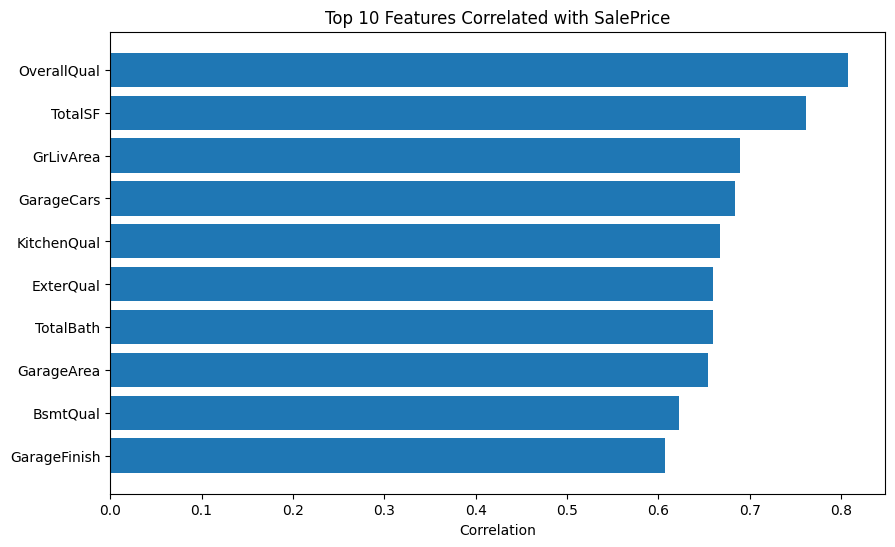

In [10]:
import matplotlib.pyplot as plt


train_for_corr = X_train.copy()
train_for_corr["SalePrice"] = y_train.values

corr = train_for_corr.corr()["SalePrice"].sort_values()

print("Most NEGATIVE correlation:\n", corr.head(10))
print("\nMost POSITIVE correlation:\n", corr.tail(10))
top_corr = corr.drop("SalePrice").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_corr.index, top_corr.values)
plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.show()

## drop features that barely changes

After dropping low variance and low correlation features, shape: (1168, 125)


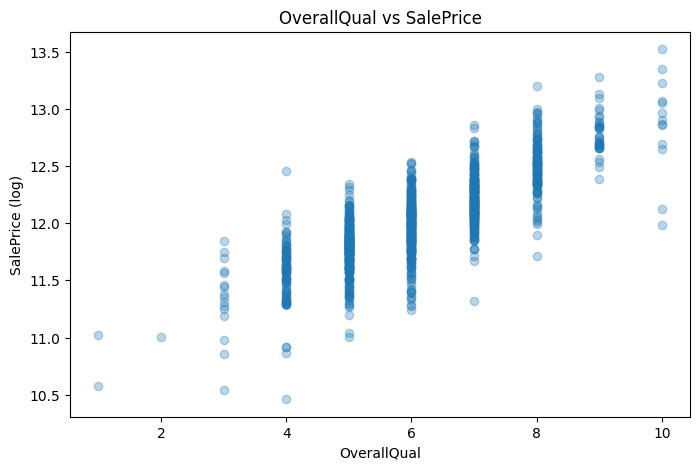

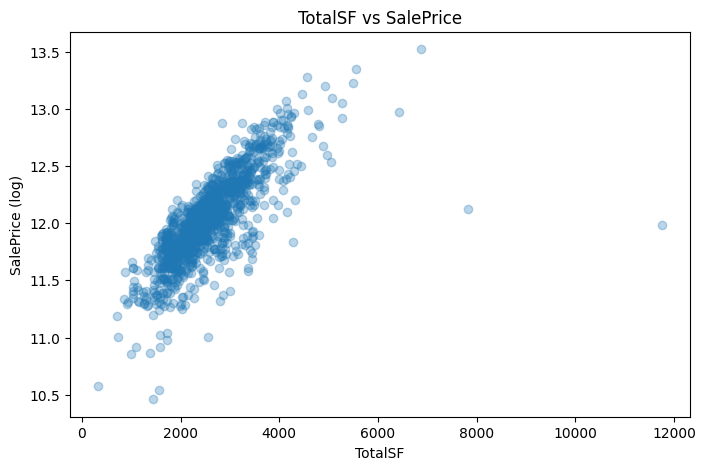

In [11]:
## drop with treshhold 0.01
variances = X_train.var()
low_var_cols = variances[variances < 0.01].index.tolist()

#drop with correlation treshhold 0.05
low_corr_cols = corr[abs(corr) < 0.05].index.tolist()
cols_to_drop = set(low_var_cols + low_corr_cols)
cols_to_drop.discard("SalePrice") 
cols_to_drop = [col for col in cols_to_drop if col in X_train.columns]
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
print("After dropping low variance and low correlation features, shape:", X_train.shape)
plt.figure(figsize=(8, 5))
plt.scatter(X_train["OverallQual"], y_train, alpha=0.3)
plt.title("OverallQual vs SalePrice")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice (log)")
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(X_train["TotalSF"], y_train, alpha=0.3)
plt.title("TotalSF vs SalePrice")
plt.xlabel("TotalSF")
plt.ylabel("SalePrice (log)")
plt.show()


## mlflow

In [12]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

mlflow.set_experiment("house-prices")

def rmse(y_true, y_pred):
    total = 0
    for i in range(len(y_true)):
        total = total + (y_true.iloc[i] - y_pred[i]) ** 2
    mean = total / len(y_true)
    return np.sqrt(mean)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## train

In [13]:
for col in X_train.columns:
    if X_train[col].dtype == "object":
        print(col)
print(X_train.dtypes.value_counts())
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in y_train:", y_train.isnull().sum())

int64      121
float64      4
Name: count, dtype: int64
NaN values in X_train: 0
NaN values in y_train: 0


In [14]:
with mlflow.start_run(run_name="linear_regression"):
    model = LinearRegression()
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Validation RMSE: {val_rmse:.4f}")

2026/04/10 16:32:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:32:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.1196
Validation RMSE: 0.1581
🏃 View run linear_regression at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/8fe6cf4046f44ad69d77a4ec38f9558e
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [ ]:
from sklearn.ensemble import RandomForestRegressor

with mlflow.start_run(run_name="random_forest_overfit"):
    
    model = RandomForestRegressor(n_estimators=500, max_depth=None, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train) 
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("max_depth", "None")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:33:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:33:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.0529
Val RMSE: 0.1491
🏃 View run random_forest_overfit at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/e1029d9b0cfc44ff82ab0c332e0c55d3
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [16]:
from sklearn.ensemble import RandomForestRegressor

with mlflow.start_run(run_name="random_forest_overfit"):
    
    model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train) 
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:35:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:35:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.0593
Val RMSE: 0.1503
🏃 View run random_forest_overfit at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/132fc9fa106046a986ee3680a87a0cac
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [17]:
with mlflow.start_run(run_name="random_forest_tuned"):
    model = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=4, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("min_samples_leaf", 4)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:37:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:37:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.1079
Val RMSE: 0.1564
🏃 View run random_forest_tuned at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/53d54a2e25e14fc0a40f625efafa53ea
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [18]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run(run_name="decision_tree_overfit"):
    model = DecisionTreeRegressor(max_depth=None, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", "None")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:37:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:37:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.0
Val RMSE: 0.2046
🏃 View run decision_tree_overfit at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/1d47bb758fd04fa381c07723f22a4220
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [19]:
with mlflow.start_run(run_name="decision_tree_tuned"):
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:37:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:37:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.1504
Val RMSE: 0.1974
🏃 View run decision_tree_tuned at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/055fd1bc8a98424786ffb826074ceece
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [20]:
from sklearn.ensemble import GradientBoostingRegressor

with mlflow.start_run(run_name="gradient_boosting"):
    model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 4)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:38:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:38:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.0461
Val RMSE: 0.1402
🏃 View run gradient_boosting at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/f6204d2eb4df433a81773750db57762e
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [ ]:
import pickle

with open("models/gradient_boosting_best.pkl", "wb") as f:
    pickle.dump(model, f)


In [ ]:
with mlflow.start_run(run_id="f6204d2eb4df433a81773750db57762e"):
    mlflow.sklearn.log_model(model, "model")
    

2026/04/10 17:19:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 17:19:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


artifact uploaded!
🏃 View run gradient_boosting at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/f6204d2eb4df433a81773750db57762e
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [22]:
from sklearn.linear_model import Ridge

with mlflow.start_run(run_name="ridge_regression"):
    model = Ridge(alpha=10)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", 10)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:38:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:38:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.122
Val RMSE: 0.1475
🏃 View run ridge_regression at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/de218ebed26c46969fcf913c178c790c
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [23]:
with mlflow.start_run(run_name="gradient_boosting_overfit"):
    model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:39:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:39:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.0008
Val RMSE: 0.149
🏃 View run gradient_boosting_overfit at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/dd8cc2f690314c53b39fd088c2a86c60
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


In [24]:
with mlflow.start_run(run_name="ridge_alpha_100"):
    model = Ridge(alpha=100)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_rmse = rmse(y_train, train_pred)
    val_rmse = rmse(y_val, val_pred)
    
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", 100)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(model, "model")
    
    print("Train RMSE:", round(train_rmse, 4))
    print("Val RMSE:", round(val_rmse, 4))

2026/04/10 16:39:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 16:39:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0.1302
Val RMSE: 0.1486
🏃 View run ridge_alpha_100 at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0/runs/00e45d66096a4600a21ec94a7d74a757
🧪 View experiment at: https://dagshub.com/karev23/ML-HW-1.mlflow/#/experiments/0


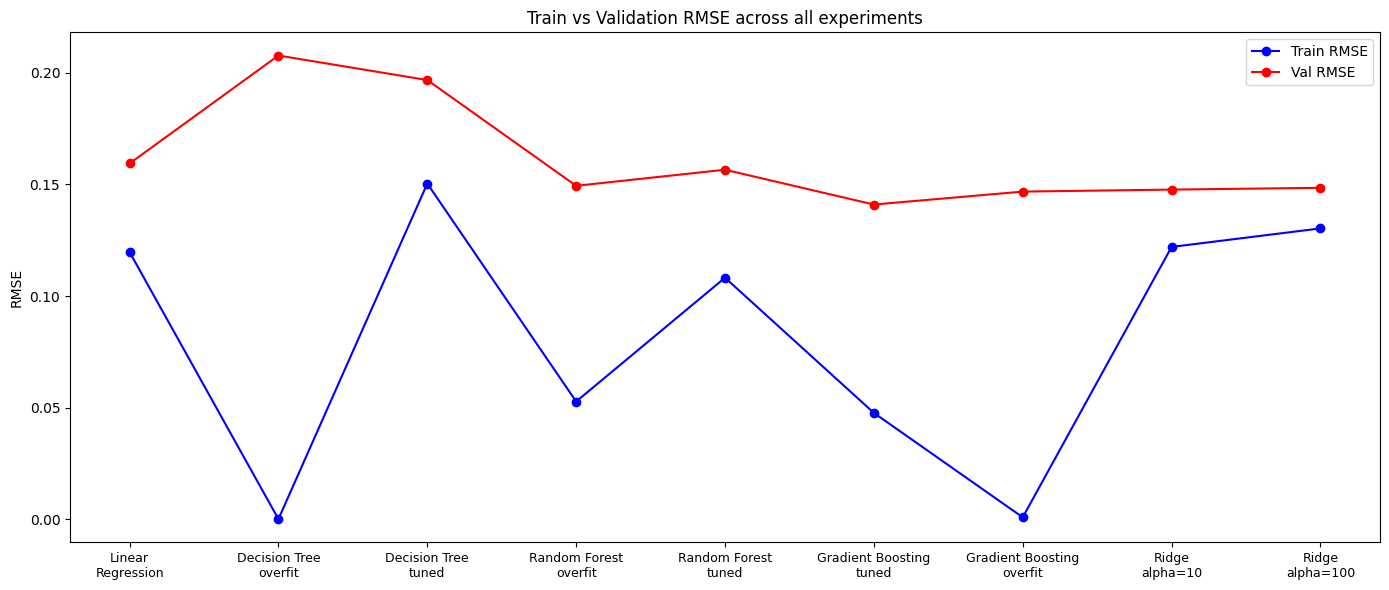

In [25]:
import matplotlib.pyplot as plt

models = ["Linear\nRegression", "Decision Tree\noverfit", "Decision Tree\ntuned", 
          "Random Forest\noverfit", "Random Forest\ntuned", "Gradient Boosting\ntuned",
          "Gradient Boosting\noverfit", "Ridge\nalpha=10", "Ridge\nalpha=100"]

train_scores = [0.1197, 0.0, 0.1504, 0.0527, 0.1082, 0.0476, 0.0008, 0.122, 0.1303]
val_scores =   [0.1594, 0.2078, 0.1968, 0.1494, 0.1566, 0.141, 0.1468, 0.1477, 0.1485]

x = range(len(models))

plt.figure(figsize=(14, 6))
plt.plot(x, train_scores, marker="o", label="Train RMSE", color="blue")
plt.plot(x, val_scores, marker="o", label="Val RMSE", color="red")
plt.xticks(x, models, fontsize=9)
plt.title("Train vs Validation RMSE across all experiments")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
import mlflow
from mlflow.tracking import MlflowClient

best_run_id = "867976603a40454183ac933e1aaebb17"
model_uri = "runs:/" + best_run_id + "/model"

client = MlflowClient()
client.create_model_version(
    name="house-prices-best-model",
    source=model_uri,
    run_id=best_run_id
)


2026/04/10 16:39:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house-prices-best-model, version 3


<ModelVersion: aliases=[], creation_timestamp=1775824785997, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1775824785997, metrics=None, model_id=None, name='house-prices-best-model', params=None, run_id='867976603a40454183ac933e1aaebb17', run_link='', source='runs:/867976603a40454183ac933e1aaebb17/model', status='READY', status_message=None, tags={}, user_id='', version='3', workspace='default'>

In [27]:
# save training columns for inference
import pickle
with open("models/train_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)
